# CSoT'26 - ML in Astronomy - Week 3 . Part 1: A CNN and the Training Loop (Starter)

**Goal:** Replace the Week-2 MLP with a **Convolutional Neural Network**, then write the **training loop** that teaches it. By the end you'll watch the training loss fall over several epochs.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). This week it actually matters for speed.
2. Read [`01-convolutions-and-pooling.md`](../01-convolutions-and-pooling.md), [`02-building-a-cnn.md`](../02-building-a-cnn.md), and [`03-the-training-loop.md`](../03-the-training-loop.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Re-create the Week 1 data pipeline

Week 3 builds directly on the `DataLoader`s from Week 1. Paste that pipeline below (download is commented out in the Week-1 solution - uncomment it the first time). If you saved `galaxy_data/` to Google Drive in Week 1, re-mount Drive and point `ImageFolder` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [4]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pandas as pd
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [3]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
#   print("classes:", train_ds.classes, "num_classes:", num_classes)

import os
import json
import shutil
from pathlib import Path

# --- 1. KAGGLE AUTHENTICATION ---
# Replace with your EXACT username and key from your Kaggle account
kaggle_creds = {
  "username": "your_username_here",
  "key": "your_long_alphanumeric_key_here"
}

# Create the hidden Kaggle directory and write the credentials file
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# Lock down the file permissions for security
!chmod 600 /root/.kaggle/kaggle.json

# --- 2. DIRECTORY SETUP ---
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"
DATA_ROOT = Path("galaxy_data")
RAW_ROOT.mkdir(parents=True, exist_ok=True)

# --- 3. DOWNLOAD KAGGLE IMAGES ---
print("Authenticating and downloading images from Kaggle. This might take a minute...")
dataset_name = "jaimetrickz/galaxy-zoo-2-images"
!kaggle datasets download -d {dataset_name} -p {RAW_ROOT} --unzip

# --- 4. DOWNLOAD HART LABELS ---
print("Downloading Hart et al. morphology labels...")
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

# --- 5. FIX NESTED DIRECTORY ---
# Kaggle sometimes double-wraps the extracted folder. This flattens it.
nested_dir = IMAGES_DIR / "images_gz2"

if nested_dir.exists() and nested_dir.is_dir():
    print("Flattening the nested image directory...")
    for file in nested_dir.glob("*.jpg"):
        shutil.move(str(file), str(IMAGES_DIR))
    nested_dir.rmdir() # Clean up the empty duplicate folder

import shutil

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("Hunting for the hidden images...")

# Recursively find ALL jpg files anywhere inside RAW_ROOT
all_jpgs = list(RAW_ROOT.rglob("*.jpg"))
print(f"Found {len(all_jpgs)} total images hiding in the raw folder!")

if len(all_jpgs) > 0:
    print("Moving them to the correct IMAGES_DIR... (This might take a minute)")

    # Ensure IMAGES_DIR exists
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

    # Move them all to the flat directory
    moved_count = 0
    for img_path in all_jpgs:
        # Only move if it's not already in the right spot
        if img_path.parent != IMAGES_DIR:
            shutil.move(str(img_path), str(IMAGES_DIR / img_path.name))
            moved_count += 1

    print(f"Successfully moved {moved_count} images!")

# Final Recount
print("\n--- Final Image Recount ---")
image_count = len(list(IMAGES_DIR.glob('*.jpg')))
print(f"Total images exactly in target folder: {image_count}")

if image_count > 240000:
    print("✅ Found them! Data pipeline setup successful! Ready for Step 2.")
else:
    print("⚠️ Warning: Something is still odd. Let me know what it prints!")



# --- 6. FINAL SANITY CHECK ---
print("\n--- Final Download Check ---")
print(f"Mapping CSV exists: {(RAW_ROOT / 'gz2_filename_mapping.csv').exists()}")
print(f"Hart labels CSV exists: {(RAW_ROOT / 'gz2_hart16.csv').exists()}")
print(f"Images folder exists: {IMAGES_DIR.exists()}")

if IMAGES_DIR.exists():
    image_count = len(list(IMAGES_DIR.glob('*.jpg')))
    print(f"Total images found: {image_count}")
    if image_count > 240000:
        print("✅ Data pipeline setup successful! Ready for Step 2.")
    else:
        print("⚠️ Warning: Image count seems low.")
# Assuming these are still set from the previous cell



Authenticating and downloading images from Kaggle. This might take a minute...
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
Resuming from 1021313024 bytes (2260549684 bytes left)...
100% 3.06G/3.06G [00:26<00:00, 83.9MB/s]

Hunting for the hidden images...
Found 243434 total images hiding in the raw folder!
Moving them to the correct IMAGES_DIR... (This might take a minute)
Successfully moved 243434 images!

--- Final Image Recount ---
Total images exactly in target folder: 243434
✅ Found them! Data pipeline setup successful! Ready for Step 2.

--- Final Download Check ---
Mapping CSV exists: True
Hart labels CSV exists: True
Images folder exists: True
Total images found: 243434
✅ Data pipeline setup successful! Ready for Step 2.
--- 1. Contents of RAW_ROOT ---
 - gz2_filename_mapping.csv
 - gz2_hart16.csv
 - images_gz2

--- 2. Peek at IMAGES_DIR ---
 - 163838.jpg
 - 164907.jpg
 - 120782.jpg
 - 196933

NameError: name 'pd' is not defined

In [5]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("--- 1. Contents of RAW_ROOT ---")
# List everything sitting in the raw folder
for item in RAW_ROOT.iterdir():
    print(f" - {item.name}")

print("\n--- 2. Peek at IMAGES_DIR ---")
# Grab just the first 5 jpg files to verify the naming convention
sample_images = list(IMAGES_DIR.glob('*.jpg'))[:5]
for img in sample_images:
    print(f" - {img.name}")

print("\n--- 3. Checking gz2_filename_mapping.csv ---")
mapping_csv_path = RAW_ROOT / "gz2_filename_mapping.csv"

if mapping_csv_path.exists():
    # Load the CSV into a pandas DataFrame
    df_mapping = pd.read_csv(mapping_csv_path)

    print("Columns found:")
    print(df_mapping.columns.tolist())

    print("\nFirst 3 rows:")
    # Display the first few rows to see the actual data
    display(df_mapping.head(3))

    # Programmatic check for the specific columns
    expected_cols = {'objid', 'sample', 'asset_id'}
    actual_cols = set(df_mapping.columns)

    if expected_cols.issubset(actual_cols):
        print("\n✅ Success: Expected columns (objid, sample, asset_id) are all present!")
    else:
        print("\n⚠️ Warning: Missing expected columns.")
else:
    print(f"⚠️ Error: Could not find {mapping_csv_path}")


def high_level_label(gz2_class):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, ...) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    return df.dropna(subset=["label"]).reset_index(drop=True)


def _link_image(src, dst):
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(images_dir, df, out_root, per_class=200,
                                   train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    images_dir, out_root = Path(images_dir), Path(out_root)
    summary = {}
    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)
        n = len(rows)
        n_train = int(train_frac * n); n_val = int(val_frac * n)
        splits = {"train": rows.iloc[:n_train],
                  "val": rows.iloc[n_train:n_train + n_val],
                  "test": rows.iloc[n_train + n_val:]}
        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

# Uncomment once the raw data is downloaded:
df = load_labeled_table(RAW_ROOT / "gz2_filename_mapping.csv", RAW_ROOT / "gz2_hart16.csv")
build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=200)
print("layout built")


--- 1. Contents of RAW_ROOT ---
 - gz2_filename_mapping.csv
 - gz2_hart16.csv
 - images_gz2

--- 2. Peek at IMAGES_DIR ---
 - 163838.jpg
 - 164907.jpg
 - 120782.jpg
 - 196933.jpg
 - 96652.jpg

--- 3. Checking gz2_filename_mapping.csv ---
Columns found:
['objid', 'sample', 'asset_id']

First 3 rows:


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3



✅ Success: Expected columns (objid, sample, asset_id) are all present!
layout built


In [6]:

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "| num_classes:", num_classes)

classes: ['elliptical', 'spiral', 'spiral_barred'] | num_classes: 3


## Step 1 - Define the CNN

Two `Conv -> ReLU -> Pool` blocks (channels `3 -> 16 -> 32`, each conv `kernel_size=3, padding=1`), then a `Flatten -> Linear -> ReLU -> Linear` head. With a 64x64 input and two 2x2 pools, the feature maps are `(B, 32, 16, 16)`, so the flattened size is `32*16*16 = 8192`. The final layer returns **raw logits** (no softmax). Don't forget `super().__init__()`.

In [7]:
# TODO: define GalaxyCNN(nn.Module).
#   features = nn.Sequential(
#       nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#       nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
#   classifier = nn.Sequential(
#       nn.Flatten(), nn.Linear(32*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))
#   forward(x): x = features(x); x = classifier(x); return x


class GalaxyCNN(nn.Module):
  def __init__(self, nums_classes=3):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )
# classifier head

    self.classifer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32*16*16, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes),
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifer(x)
    return x


## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [8]:
# TODO: model = GalaxyCNN(num_classes=num_classes).to(device)
#       print(model)

model = GalaxyCNN(nums_classes=3)
model = model.to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 - Forward-pass one real batch and count parameters

Pull a batch from `train_loader`, move it to the device, and confirm the output is `(batch_size, num_classes)`. Then print the parameter count - notice the convolutions are tiny and the first `Linear` dominates (compare with the Week-2 MLP's ~1.57M first layer).

In [19]:
# TODO: images, labels = next(iter(train_loader)); move both to device.
#       logits = model(images); print(logits.shape)  # expect (B, num_classes)
#       total = sum(p.numel() for p in model.parameters()); print(f"params: {total:,}")
image, labels = next(iter(train_loader))
image = image.to(device)
labels = labels.to(device)
logits = model(image)
print(logits.shape)
total = sum(p.numel() for p in model.parameters())
print(f"params: {total:,}")

torch.Size([32, 3])
params: 1,054,179


## Step 4 - Loss, optimiser, and a starting-loss sanity check

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default. An untrained model on `C` balanced classes should give a loss near `ln(C)`.

In [20]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = optim.Adam(model.parameters(), lr=1e-3)
#       loss = criterion(logits, labels); print(loss.item(), "vs ln(C) =", math.log(num_classes))


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
loss = criterion(logits, labels)
print(loss.item(), "vs ln(c) =", math.log(num_classes))

0.9044829607009888 vs ln(c) = 1.0986122886681098


## Step 5 - The training loop

For each epoch, loop over `train_loader` and run the **five steps** every batch: `zero_grad -> forward -> loss -> backward -> step`. Accumulate a running loss and store the epoch average in `train_losses`. Call `model.train()` at the start of each epoch and `.to(device)` every batch.

In [17]:
# TODO: write the training loop.
#   num_epochs = 8
#   train_losses = []
#   for epoch in range(num_epochs):
#       model.train(); running = 0.0
#       for inputs, targets in train_loader:
#           inputs, targets = inputs.to(device), targets.to(device)
#           optimizer.zero_grad()
#           outputs = model(inputs)
#           loss = criterion(outputs, targets)
#           loss.backward()
#           optimizer.step()
#           running += loss.item() * inputs.size(0)
#       epoch_loss = running / len(train_loader.dataset)
#       train_losses.append(epoch_loss)
#       print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")4

num_epochs = 8
train_losses = []
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)

  epoch_loss = running_loss / len(train_loader.dataset)
  train_losses.append(epoch_loss)
  print(f"Epoch {epoch+1:2d}/{num_epochs} train loss: {epoch_loss:.4f}")

Epoch  1/8 train loss: 0.9305
Epoch  2/8 train loss: 0.9260
Epoch  3/8 train loss: 0.9216
Epoch  4/8 train loss: 0.9184
Epoch  5/8 train loss: 0.9164
Epoch  6/8 train loss: 0.9142
Epoch  7/8 train loss: 0.9121
Epoch  8/8 train loss: 0.9104


## Step 6 - Plot the loss curve

A healthy run shows `train_losses` trending **down**. Small wiggles are fine; the trend is what matters.

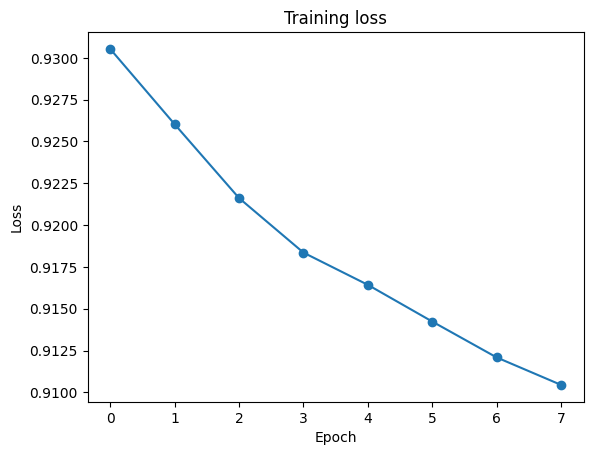

In [25]:
plt.plot(train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.show()

## Step 7 (stretch) - Save Part 1's weights for Part 2

Optional but handy: save the trained weights so the Part-2 notebook can load them instead of re-training. Save to Drive so they survive a runtime recycle. (Saving/loading is covered fully in [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).)

In [26]:
# TODO (optional): torch.save(model.state_dict(), 'galaxy_model.pth'); print('saved')


torch.save(model.state_dict(), 'galaxy_model.pth'); print('saved')



saved


## Reflection *(write 2-3 sentences each)*

1. Your CNN's parameter count - where do most of the weights live, and why is that different from the Week-2 MLP?
2. Describe the shape of your training-loss curve. What would it mean if the loss never fell? If it went to `nan`?
3. Low training loss is necessary but not sufficient. What does Part 2 add to check the model is actually good?

*(
1. In the linear flattening of the pixels. Because in this part we have also introduces the convolution which take few thousands parameters and do the hard visual work.

2. It's a decreasing curve(very close to linear decresing curve). If the loss curve is constant it means my model is never learning! nan implies diverging.

3. Catching the gap between training and validating the performance(overfitting) )*